In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import json
from collections import Counter, defaultdict
import os
from sklearn.manifold import TSNE

# ---------------------- Load dữ liệu ----------------------
features = np.load("../datasets/raw_data/AwA2-features.npy")  # (N, D)
df_test = pd.read_csv("../datasets/clean_data/test_data.csv")
df_test = df_test.reset_index().rename(columns={"index": "sample_index"})

# Dùng clean_data để ánh xạ label → tên lớp
df = pd.read_csv("../datasets/preprocessing_data/clean_data.csv")
label_to_name = dict(zip(df['label'], df['class_name']))

# ---------------------- Đường dẫn mô hình ----------------------
model_paths = {
    "Logistic Regression": "../checkpoints/awa2_logistic/predictions.json",
    "Random Forest": "../checkpoints/awa2_random_forest/predictions.json",
    "SVM": "../checkpoints/awa2_svm/predictions.json"
}

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
import os

# Đường dẫn đến các checkpoint
models = ['logistic', 'random_forest', 'svm']
base_path = '../checkpoints/awa2_{}'

classification_reports = {}
metrics = {}
predictions = {}

# Đọc các file JSON
for model in models:
    model_path = base_path.format(model)
    
    with open(os.path.join(model_path, 'test_classification_report.json')) as f:
        classification_reports[model] = json.load(f)
        
    with open(os.path.join(model_path, 'test_metrics.json')) as f:
        metrics[model] = json.load(f)
        
    with open(os.path.join(model_path, 'predictions.json')) as f:
        predictions[model] = json.load(f)

# 1. Tổng hợp metrics
summary_df = pd.DataFrame.from_dict({m: metrics[m] for m in models}, orient='index')
print("== Tổng quan các chỉ số ==")
print(summary_df)


== Tổng quan các chỉ số ==
               accuracy  precision_macro  recall_macro  f1_macro  f1_micro  \
logistic       0.928737         0.895039      0.900987  0.897574  0.928737   
random_forest  0.903197         0.877169      0.840284  0.847027  0.903197   
svm            0.936596         0.916857      0.899924  0.906573  0.936596   

               f1_weighted  
logistic          0.929041  
random_forest     0.897718  
svm               0.935761  


| Mô hình           | Accuracy   | F1\_macro  | F1\_micro  | F1\_weighted | CV Score | Training Time  | Tuning Time       | Tổng thời gian      |
| ----------------- | ---------- | ---------- | ---------- | ------------ | -------- | -------------- | ----------------- | ------------------- |
| **SVM**           | **0.9366** | **0.9066** | **0.9366** | **0.9358**   | 0.8956   | 9 phút 53 giây | 8 phút 59 giây    | \~18 phút 52 giây   |
| **Logistic Reg.** | 0.9287     | 0.8976     | 0.9287     | 0.9290       | 0.8976   | 1 phút 13 giây | **2 giờ 12 phút** | **\~2 giờ 13 phút** |
| **Random Forest** | 0.9032     | 0.8470     | 0.9032     | 0.8977       | 0.8816   | 12 phút 6 giây | 6 phút 57 giây    | \~19 phút 3 giây    |


| Mô hình                 | Ưu điểm                                                                                             | Nhược điểm                           | Đánh giá        |
| ----------------------- | --------------------------------------------------------------------------------------------------- | ------------------------------------ | --------------- |
| **SVM**                 | Chính xác cao nhất, cân bằng tốt giữa Precision và Recall, mạnh cả trên lớp phổ biến và ít phổ biến | Có thể tốn tài nguyên huấn luyện hơn | ⭐ Tốt nhất      |
| **Logistic Regression** | Hiệu quả gần với SVM, đơn giản, nhanh                                                         | Không bằng SVM về mặt macro          | 👍 Tốt          |
| **Random Forest**       | Tốt nhưng bỏ sót nhiều mẫu ở lớp hiếm (recall thấp)                                                 | F1\_macro và Recall\_macro thấp nhất | ❗ Cần cải thiện |


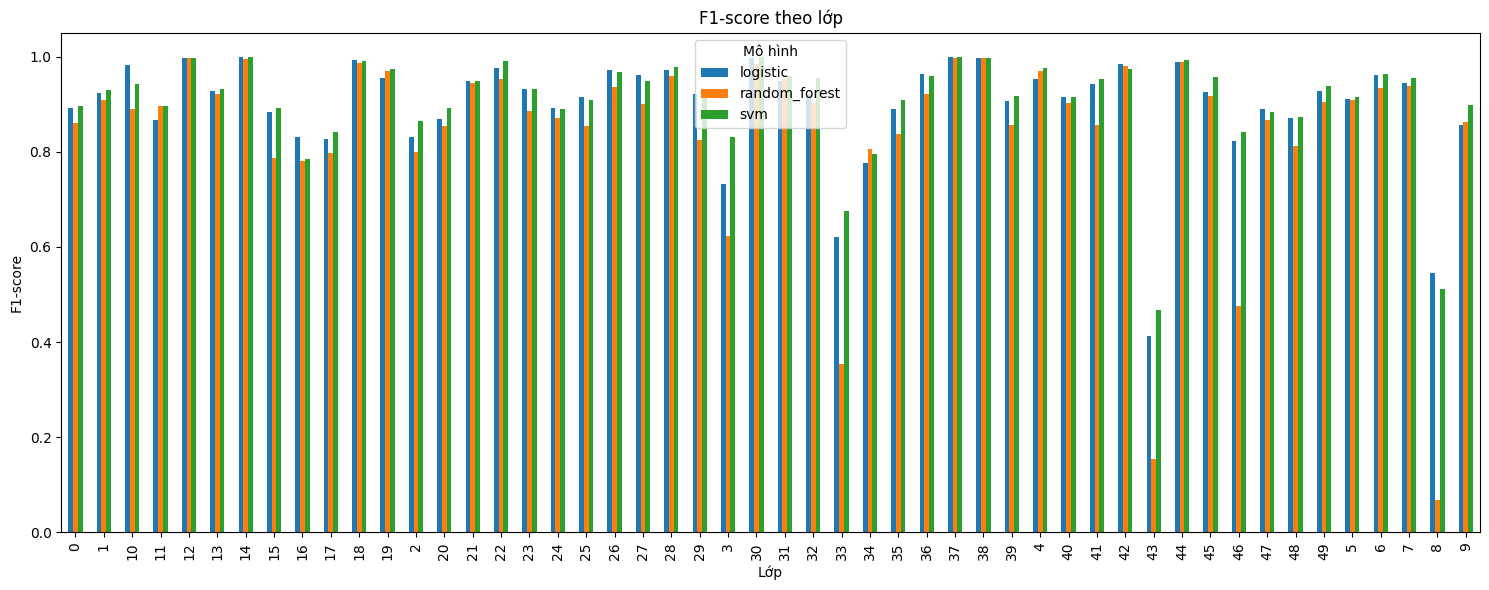

In [3]:
# 2. So sánh F1-score theo lớp
f1_df = pd.DataFrame({
    model: {
        label: float(classification_reports[model][label]['f1-score']) 
        for label in classification_reports[model] if label not in ['accuracy', 'macro avg', 'weighted avg']
    }
    for model in models
}).sort_index()

f1_df.plot(kind='bar', figsize=(15, 6), title="F1-score theo lớp")
plt.ylabel("F1-score")
plt.xlabel("Lớp")
plt.legend(title="Mô hình")
plt.tight_layout()
plt.show()

In [4]:
# ---------------------- 1. Import thư viện ----------------------
import json
import collections
import os

# ---------------------- 2. Tạo mapping từ label sang tên động vật ----------------------
label_to_name = dict(zip(df['label'], df['class_name']))

# ---------------------- 4. Hàm phân tích nhầm lẫn ----------------------
def get_top_confused(predictions, label_to_name, top_k=5):
    pairs = [
        (item["target"], item["prediction"])
        for item in predictions
        if item["target"] != item["prediction"]
    ]
    counter = collections.Counter(pairs)
    top_confused = counter.most_common(top_k)

    print(f"\n🎯 Top {top_k} cặp lớp bị nhầm nhiều nhất:")
    for (true_label, pred_label), count in top_confused:
        true_name = label_to_name.get(true_label, f"Label {true_label}")
        pred_name = label_to_name.get(pred_label, f"Label {pred_label}")
        print(f"- {true_name} → {pred_name}: {count} lần")
    
    return top_confused

# ---------------------- 5. Hàm in ví dụ cụ thể ----------------------
def show_example_errors(predictions, true_label, pred_label, label_to_name, n=3):
    true_name = label_to_name.get(true_label, f"Label {true_label}")
    pred_name = label_to_name.get(pred_label, f"Label {pred_label}")
    print(f"\n📌 Ví dụ sai nhãn: {true_name} → {pred_name}")
    cnt = 0
    for item in predictions:
        if item["target"] == true_label and item["prediction"] == pred_label:
            print(f"  - Index: {item.get('index', '?')} | Prediction: {pred_name}")
            cnt += 1
            if cnt >= n:
                break
    if cnt == 0:
        print("  → Không tìm thấy ví dụ.")

# ---------------------- 6. Chạy cho từng mô hình ----------------------
for model_name, pred_path in model_paths.items():
    print("=" * 60)
    print(f"🧠 Phân tích lỗi cho mô hình: {model_name}")
    print("=" * 60)

    if not os.path.exists(pred_path):
        print(f"⚠️ File không tồn tại: {pred_path}")
        continue

    with open(pred_path) as f:
        predictions_raw = json.load(f)

    # Chuẩn hóa định dạng: dict → list
    if isinstance(predictions_raw, dict):
        predictions = list(predictions_raw.values())
    elif isinstance(predictions_raw, list):
        predictions = predictions_raw
    else:
        print("❌ predictions.json không đúng định dạng")
        continue

    # Top confused classes
    top_confused = get_top_confused(predictions, label_to_name, top_k=5)

    # In ví dụ cho cặp đầu tiên bị nhầm
    if top_confused:
        show_example_errors(
            predictions,
            true_label=top_confused[0][0][0],
            pred_label=top_confused[0][0][1],
            label_to_name=label_to_name,
            n=3
        )


🧠 Phân tích lỗi cho mô hình: Logistic Regression

🎯 Top 5 cặp lớp bị nhầm nhiều nhất:
- humpback whale → blue whale: 14 lần
- antelope → deer: 14 lần
- deer → antelope: 12 lần
- cow → ox: 11 lần
- ox → cow: 10 lần

📌 Ví dụ sai nhãn: humpback whale → blue whale
  - Index: ? | Prediction: blue whale
  - Index: ? | Prediction: blue whale
  - Index: ? | Prediction: blue whale
🧠 Phân tích lỗi cho mô hình: Random Forest

🎯 Top 5 cặp lớp bị nhầm nhiều nhất:
- antelope → deer: 24 lần
- blue whale → humpback whale: 24 lần
- rat → hamster: 20 lần
- walrus → seal: 14 lần
- ox → cow: 11 lần

📌 Ví dụ sai nhãn: antelope → deer
  - Index: ? | Prediction: deer
  - Index: ? | Prediction: deer
  - Index: ? | Prediction: deer
🧠 Phân tích lỗi cho mô hình: SVM

🎯 Top 5 cặp lớp bị nhầm nhiều nhất:
- antelope → deer: 15 lần
- blue whale → humpback whale: 14 lần
- ox → cow: 12 lần
- deer → antelope: 9 lần
- cow → ox: 8 lần

📌 Ví dụ sai nhãn: antelope → deer
  - Index: ? | Prediction: deer
  - Index: ? | Predi

| Mô hình                 | Cặp lớp nhầm lẫn            | Số lần |
| ----------------------- | --------------------------- | ------ |
| **Logistic Regression** | humpback whale → blue whale | 14     |
|                         | antelope → deer             | 14     |
|                         | deer → antelope             | 12     |
|                         | cow → ox                    | 11     |
|                         | ox → cow                    | 10     |
| **Random Forest**       | antelope → deer             | 24     |
|                         | blue whale → humpback whale | 24     |
|                         | rat → hamster               | 20     |
|                         | walrus → seal               | 14     |
|                         | ox → cow                    | 11     |
| **SVM**                 | antelope → deer             | 15     |
|                         | blue whale → humpback whale | 14     |
|                         | ox → cow                    | 12     |
|                         | deer → antelope             | 9      |
|                         | cow → ox                    | 8      |

| Cặp lớp nhầm lẫn                | Tổng số lần bị nhầm |
| ------------------------------- | ------------------- |
| **antelope → deer**             | **53**              |
| **blue whale → humpback whale** | **38**              |
| **ox → cow**                    | **34**              |
| **deer → antelope**             | **21**              |
| **cow → ox**                    | **19**              |
| **humpback whale → blue whale** | 14                  |
| **rat → hamster**               | 20                  |
| **walrus → seal**               | 14                  |


In [5]:
import json
import pandas as pd
import os

# ------------ 1. Danh sách cặp dễ bị nhầm lẫn ------------
confused_pairs = [
    (17, 8),   # humpback whale → blue whale
    (0, 39),   # antelope → deer
    (39, 0),   # deer → antelope
    (48, 20),  # cow → ox
    (20, 48),  # ox → cow
    (8, 17),   # blue whale → humpback whale
    (33, 25),  # rat → hamster
    (46, 23),  # walrus → seal
]

# ------------ 2. Hàm load dự đoán và gán index mặc định ------------

def load_predictions(path):
    with open(path) as f:
        pred_raw = json.load(f)
    
    df_pred = pd.DataFrame(pred_raw).T
    df_pred = df_pred.astype({'target': int, 'prediction': int})
    
    # Gán chỉ số dòng mặc định làm sample_index
    df_pred = df_pred.reset_index(drop=True)
    df_pred["sample_index"] = df_pred.index
    
    return df_pred

# ------------ 3. Gộp tất cả lỗi nhầm từ các mô hình ------------

records = []

for model_name, path in model_paths.items():
    if not os.path.exists(path):
        continue
    
    df_pred = load_predictions(path)
    
    for true, pred in confused_pairs:
        mask = ((df_pred["target"] == true) & (df_pred["prediction"] == pred)) | \
               ((df_pred["target"] == pred) & (df_pred["prediction"] == true))
        
        df_conf = df_pred[mask].copy()
        df_conf["true_name"] = df_conf["target"].map(label_to_name)
        df_conf["pred_name"] = df_conf["prediction"].map(label_to_name)
        df_conf["model"] = model_name
        
        records.append(df_conf)

# Gộp tất cả lỗi lại
df_all_confused = pd.concat(records, ignore_index=True)


In [6]:
# Đã có df_all_confused từ phần trước (gộp nhầm lẫn 3 mô hình)

# Nhóm theo target - prediction, đếm số model khác nhau
df_grouped = (
    df_all_confused
    .groupby(["target", "prediction"])
    .agg(num_models=("model", "nunique"), num_samples=("model", "count"))
    .reset_index()
)

# Thêm tên động vật
df_grouped["pair"] = df_grouped.apply(
    lambda r: f"{label_to_name[r['target']]} ↔ {label_to_name[r['prediction']]}", axis=1
)

# Lọc những cặp bị >1 model cùng nhầm
df_common_confusion = df_grouped[df_grouped["num_models"] > 1]

print("🔁 Các cặp bị từ 2 mô hình trở lên cùng nhầm:")
print(df_common_confusion[["pair", "num_models", "num_samples"]])


🔁 Các cặp bị từ 2 mô hình trở lên cùng nhầm:
                          pair  num_models  num_samples
0              antelope ↔ deer           3          106
1  blue whale ↔ humpback whale           3           94
2  humpback whale ↔ blue whale           3           44
3                     ox ↔ cow           3           66
4                seal ↔ walrus           2            4
5                hamster ↔ rat           2           11
6                rat ↔ hamster           3           32
7              deer ↔ antelope           3           62
8                walrus ↔ seal           3           22
9                     cow ↔ ox           3           58


In [7]:
import pandas as pd

# Lấy các cặp label - class_name duy nhất
labels_all = df[['label', 'class_name']].drop_duplicates().sort_values('label')

print("\n✅ Các lớp trong toàn bộ dữ liệu (clean_data.csv):")
print(labels_all.to_string(index=False))




✅ Các lớp trong toàn bộ dữ liệu (clean_data.csv):
 label      class_name
     0        antelope
     1    grizzly bear
     2    killer whale
     3          beaver
     4       dalmatian
     5     persian cat
     6           horse
     7 german shepherd
     8      blue whale
     9     siamese cat
    10           skunk
    11            mole
    12           tiger
    13    hippopotamus
    14         leopard
    15           moose
    16   spider monkey
    17  humpback whale
    18        elephant
    19         gorilla
    20              ox
    21             fox
    22           sheep
    23            seal
    24      chimpanzee
    25         hamster
    26        squirrel
    27      rhinoceros
    28          rabbit
    29             bat
    30         giraffe
    31            wolf
    32       chihuahua
    33             rat
    34          weasel
    35           otter
    36         buffalo
    37           zebra
    38     giant panda
    39            deer
    40

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# ---------------- Các cặp dễ bị nhầm ----------------
confused_pairs = [
    (17, 8),   # humpback whale ↔ blue whale
    (0, 39),   # antelope ↔ deer
    (48, 20),  # cow ↔ ox
    (33, 25),  # rat ↔ hamster
    (46, 23),  # walrus ↔ seal
]

for label_a, label_b in confused_pairs:
    # --- Lấy tên lớp ---
    name_a = label_to_name[label_a]
    name_b = label_to_name[label_b]

    # --- Lấy chỉ số mẫu theo label ---
    idx_a = df_test.index[df_test["label"] == label_a]
    idx_b = df_test.index[df_test["label"] == label_b]

    feat_a = features[idx_a]
    feat_b = features[idx_b]

    if len(feat_a) == 0 or len(feat_b) == 0:
        print(f"⚠️ Bỏ qua {name_a} ↔ {name_b} do thiếu dữ liệu.")
        continue

    print(f"\n================= 📌 {name_a} ↔ {name_b} =================")

    # 📊 1. Khoảng cách Euclidean giữa trung bình đặc trưng
    mean_a = feat_a.mean(axis=0)
    mean_b = feat_b.mean(axis=0)
    euclidean_dist = np.linalg.norm(mean_a - mean_b)
    print(f"📊 Euclidean distance: {euclidean_dist:.4f}")

    # 🧠 2. Cosine similarity giữa trung bình đặc trưng
    cos_sim = cosine_similarity(mean_a.reshape(1, -1), mean_b.reshape(1, -1))[0][0]
    print(f"🧠 Cosine similarity: {cos_sim:.4f}")



================= 📌 humpback whale ↔ blue whale =================
📊 Euclidean distance: 6.3694
🧠 Cosine similarity: 0.9615

================= 📌 antelope ↔ deer =================
📊 Euclidean distance: 3.2282
🧠 Cosine similarity: 0.9899

================= 📌 cow ↔ ox =================
📊 Euclidean distance: 3.9126
🧠 Cosine similarity: 0.9850

================= 📌 rat ↔ hamster =================
📊 Euclidean distance: 5.3382
🧠 Cosine similarity: 0.9712

================= 📌 walrus ↔ seal =================
📊 Euclidean distance: 5.6174
🧠 Cosine similarity: 0.9697


/tmp/ipykernel_13774/2069200561.py:26: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


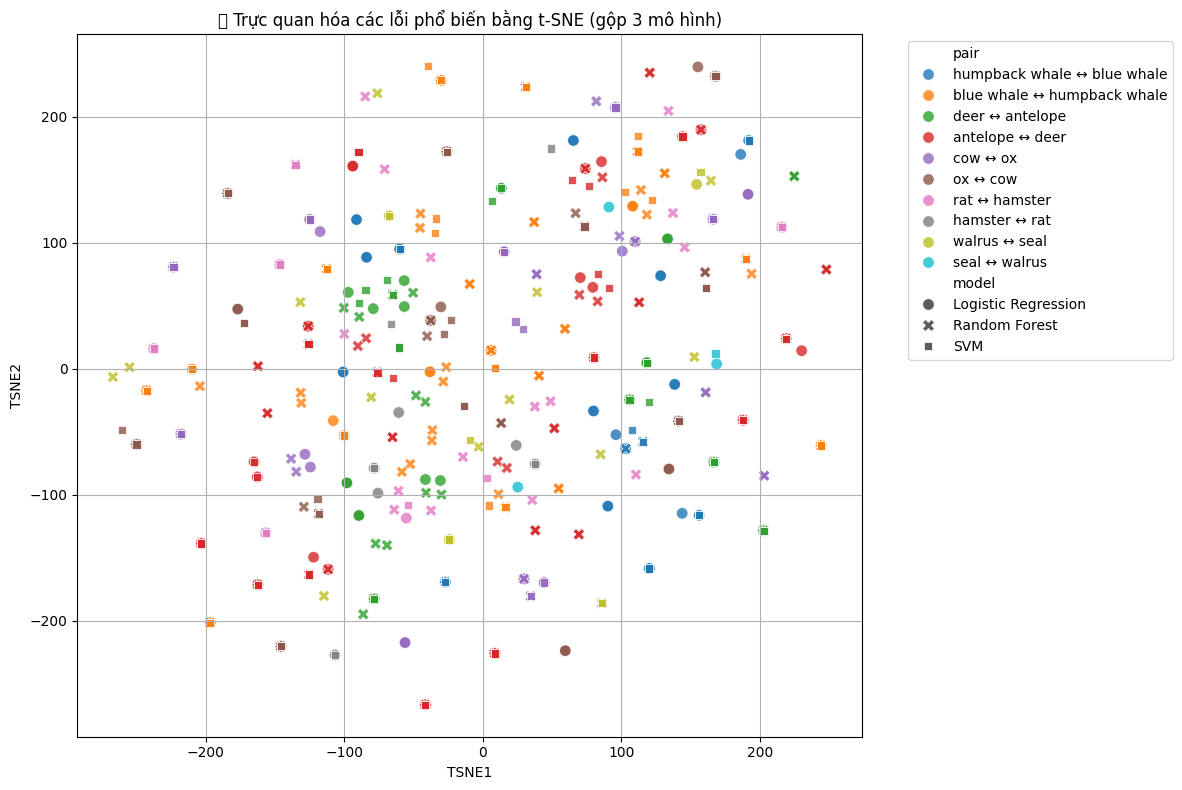

In [9]:
# Trích đặc trưng của các mẫu bị nhầm (theo chỉ số dòng)
X = features[df_all_confused["sample_index"].values]

# Giảm chiều bằng t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Thêm vào dataframe
df_all_confused["TSNE1"] = X_tsne[:, 0]
df_all_confused["TSNE2"] = X_tsne[:, 1]
df_all_confused["pair"] = df_all_confused.apply(lambda r: f"{label_to_name[r['target']]} ↔ {label_to_name[r['prediction']]}", axis=1)

# Vẽ t-SNE
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_all_confused,
    x="TSNE1", y="TSNE2",
    hue="pair",
    style="model",
    s=70,
    alpha=0.8
)
plt.title("🔍 Trực quan hóa các lỗi phổ biến bằng t-SNE (gộp 3 mô hình)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13774/2015783316.py:23: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


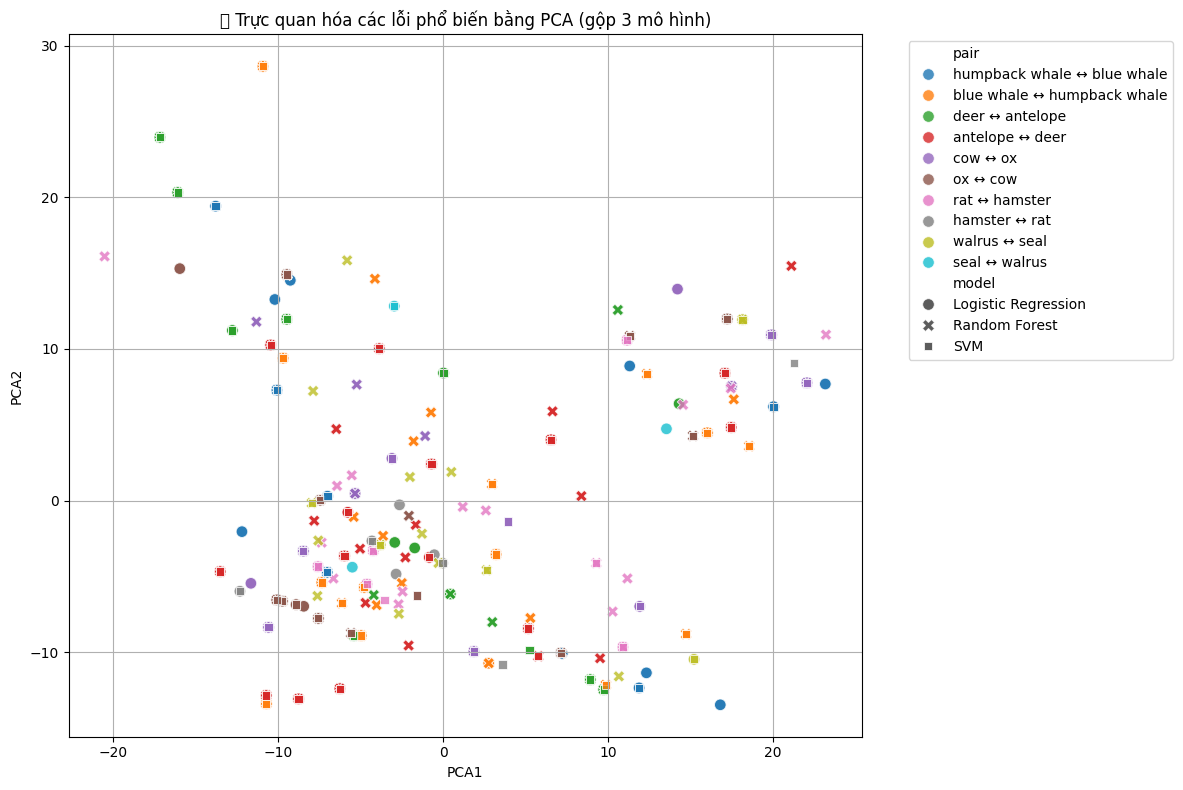

In [10]:
# Giảm chiều bằng PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Thêm vào dataframe
df_all_confused["PCA1"] = X_pca[:, 0]
df_all_confused["PCA2"] = X_pca[:, 1]
df_all_confused["pair"] = df_all_confused.apply(lambda r: f"{label_to_name[r['target']]} ↔ {label_to_name[r['prediction']]}", axis=1)

# Vẽ PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_all_confused,
    x="PCA1", y="PCA2",
    hue="pair",
    style="model",
    s=70,
    alpha=0.8
)
plt.title("🔍 Trực quan hóa các lỗi phổ biến bằng PCA (gộp 3 mô hình)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
print("Explained variance by each component:", pca.explained_variance_ratio_)


Explained variance by each component: [0.10072239 0.08468922]


Với tỷ lệ phương sai giải thích thấp, PCA không hiệu quả lắm trong việc trực quan hóa cấu trúc của các lỗi này. Điều này thường xảy ra khi dữ liệu có cấu trúc phi tuyến tính phức tạp, mà PCA (là một phương pháp tuyến tính) không thể nắm bắt được.